# Tic-Tac-Toe Assignment
**Name:** WANG Renjia

**Student ID:** 2023040901026

**Major:** Industrial Engineering

To ensure that the Jupyter Notebook renders properly to PDF, this assignment is written in English.

### Pathfinding Environment with Solvability Guarantee

This algorithm implements a grid-based environment generator specifically designed for pathfinding tasks. The core logic ensures that the generated map is functional for testing algorithms like A* or BFS by verifying connectivity.

#### Key Components:
1.  **Grid Generation**: A 2D grid is generated using a Bernoulli distribution where cells are either traversable (0) or obstacles (1) based on a defined probability ($obstacle\_prob$).
2.  **Solvability Check**: 
    * The environment uses **Breadth-First Search (BFS)** to verify if a valid path exists between the `start` and `goal` coordinates.
    * BFS is chosen for this check because it efficiently explores the reachable nodes in an unweighted graph to determine connectivity.
3.  **Iterative Refinement**:
    * If `ensure_solvable` is set to `True`, the generator enters a `while` loop.
    * If BFS fails to find a path, the random seed is incremented, and a new map is generated.
    * This process repeats until a valid path is found or a maximum attempt limit (100) is reached.
4.  **Visualization**: The `plot` method uses `matplotlib` to render the grid (binary colormap), highlighting the start/goal points and optionally displaying the search history and the final path.

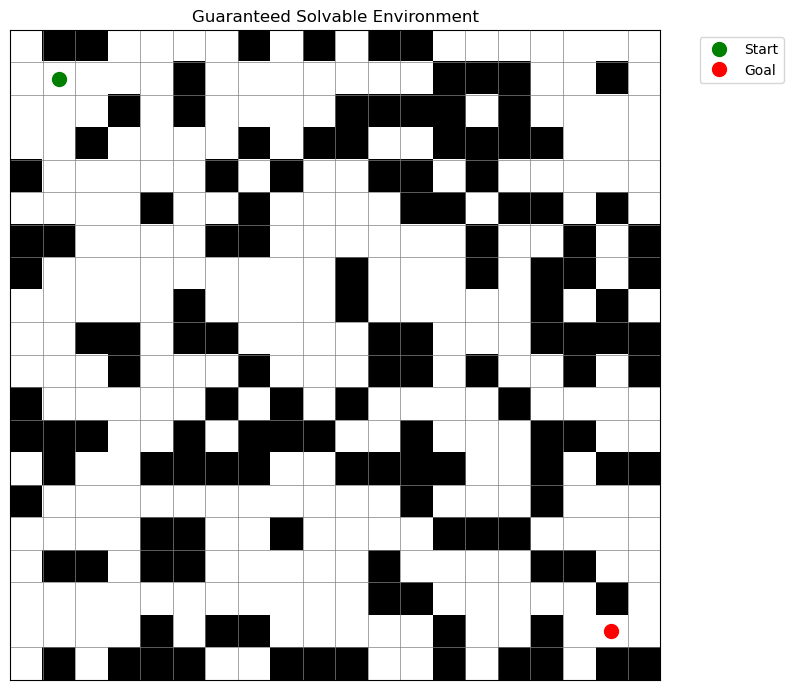

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

class PathfindingEnv:
    def __init__(self, width=20, height=20, start=(1, 1), goal=(18, 18), obstacle_prob=0.25, seed=42, ensure_solvable=True):
        self.width = width
        self.height = height
        self.start = start
        self.goal = goal
        self.obstacle_prob = obstacle_prob
        self.seed = seed
        self.ensure_solvable = ensure_solvable
        
        # Generate map (includes solvability validation logic)
        self.grid = self._generate_valid_grid()

    def _generate_valid_grid(self):
        """Generates a grid. If solvability is required, loops until a connected map is found."""
        attempt = 0
        while True:
            np.random.seed(self.seed + attempt) # Change seed slightly for each attempt
            grid = np.random.choice(
                [0, 1], 
                size=(self.height, self.width), 
                p=[1 - self.obstacle_prob, self.obstacle_prob]
            )
            grid[self.start] = 0
            grid[self.goal] = 0
            
            # Temporarily store grid in instance so get_neighbors works correctly
            self.grid = grid 
            
            if not self.ensure_solvable or self._is_solvable():
                if attempt > 0:
                    print(f"Regenerated {attempt} times to obtain a solvable map.")
                return grid
            
            attempt += 1
            if attempt > 100:
                print("Warning: Failed to generate a solvable map after 100 attempts. Please decrease obstacle_prob.")
                return grid

    def get_neighbors(self, node):
        """Get valid neighbors of the current node (Up, Down, Left, Right)"""
        y, x = node
        neighbors = []
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        
        for dy, dx in directions:
            ny, nx = y + dy, x + dx
            if 0 <= ny < self.height and 0 <= nx < self.width:
                if self.grid[ny, nx] == 0:
                    neighbors.append((ny, nx))
        return neighbors

    def _is_solvable(self):
        """Uses simple BFS to quickly check if Start and Goal are connected"""
        queue = deque([self.start])
        visited = {self.start}
        
        while queue:
            current = queue.popleft()
            if current == self.goal:
                return True
                
            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return False

    def plot(self, path=None, visited=None, title="Pathfinding Environment"):
        """Visualize the environment, search process, and final path"""
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(self.grid, cmap='binary')
        
        if visited:
            visited_y, visited_x = zip(*visited)
            ax.plot(visited_x, visited_y, 'cs', markersize=5, alpha=0.3, label="Visited Nodes")
        
        if path:
            path_y, path_x = zip(*path)
            ax.plot(path_x, path_y, 'b-', linewidth=2.5, label="Path")
            
        ax.plot(self.start[1], self.start[0], 'go', markersize=10, label="Start")
        ax.plot(self.goal[1], self.goal[0], 'ro', markersize=10, label="Goal")
        
        ax.set_xticks(np.arange(-0.5, self.width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.height, 1), minor=True)
        ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
        
        plt.title(title)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# --- Test Environment with Solvability Guarantee ---
# Set a higher obstacle probability to test the retry mechanism
env = PathfindingEnv(width=20, height=20, obstacle_prob=0.35, ensure_solvable=True)
env.plot(title="Guaranteed Solvable Environment")

### A* Pathfinding Algorithm

The A* (A-Star) algorithm is an informed search strategy used to find the shortest path between two nodes in a graph. It improves upon Dijkstra's algorithm by using a heuristic to prioritize nodes that are likely to lead toward the goal.

#### Key Concepts:
1.  **Cost Function**: A* uses a combined cost function $f(n) = g(n) + h(n)$:
    * $g(n)$: The actual cost from the start node to the current node $n$.
    * $h(n)$: The **heuristic** estimate of the cost from node $n$ to the goal.
2.  **Manhattan Distance**: In this grid environment (where only 4-directional movement is allowed), we use the Manhattan distance:
    $$h(n) = |x_n - x_{goal}| + |y_n - y_{goal}|$$
3.  **Efficiency**: By maintaining an `open_set` (priority queue) and a `g_score` map, the algorithm avoids redundant computations and always explores the node with the lowest $f(n)$ value first.
4.  **Path Reconstruction**: Once the goal is reached, the algorithm traces back through the `came_from` dictionary to return the optimal sequence of coordinates.

A* Algorithm is searching for a path...
Path found! Length: 36 steps. Explored 169 nodes.


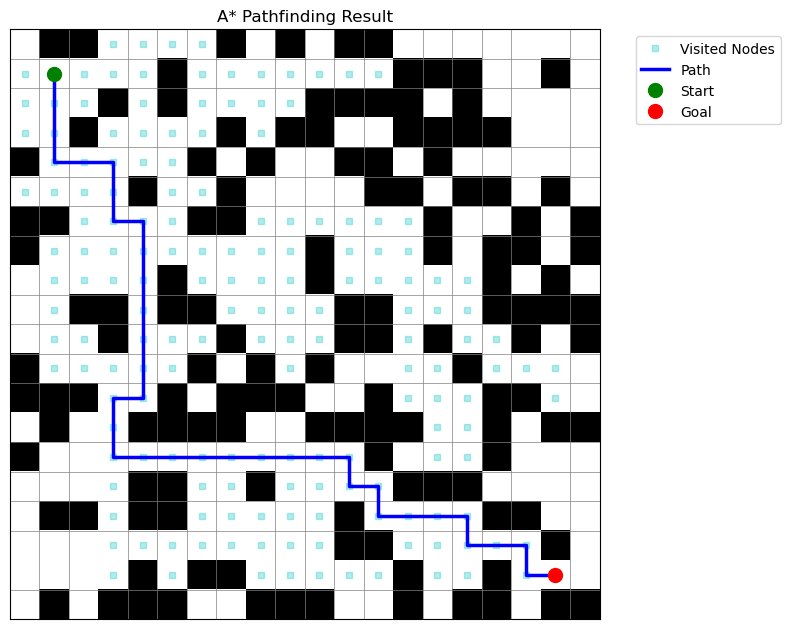

In [5]:
import heapq

class AStar:
    def __init__(self, env):
        self.env = env
        
    def heuristic(self, node, goal):
        """
        Heuristic function: Calculates Manhattan Distance.
        Used because the grid only allows Up, Down, Left, and Right movement.
        """
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])
        
    def search(self):
        start = self.env.start
        goal = self.env.goal
        
        # Priority Queue (Open Set), stored as (f_score, node_coordinates)
        open_set = []
        heapq.heappush(open_set, (0, start))
        
        # Track the origin of each node to reconstruct the final path
        came_from = {}
        
        # g_score: Cost from start to the current node (initialized to infinity)
        g_score = {start: 0}
        
        # Track nodes popped from the queue (for visualization of the search scope)
        visited = []
        
        # Auxiliary set to track nodes in the priority queue efficiently
        open_set_hash = {start}
        
        while open_set:
            # Pop the node with the lowest f_score
            current_f, current = heapq.heappop(open_set)
            open_set_hash.remove(current)
            
            # If the goal is reached, reconstruct and return the path
            if current == goal:
                visited.append(current) # Include goal in visited nodes
                path = self.reconstruct_path(came_from, current)
                return path, visited
                
            visited.append(current)
            
            # Iterate through valid neighbors of the current node
            for neighbor in self.env.get_neighbors(current):
                # In this grid, the cost for each move is 1
                tentative_g_score = g_score[current] + 1
                
                # If a better path to the neighbor is found (or it's the first time seeing it)
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    
                    # f = g + h
                    f_score = tentative_g_score + self.heuristic(neighbor, goal)
                    
                    if neighbor not in open_set_hash:
                        heapq.heappush(open_set, (f_score, neighbor))
                        open_set_hash.add(neighbor)
                        
        # If the open set is empty and goal not reached, no path exists
        return None, visited
        
    def reconstruct_path(self, came_from, current):
        """Backtracks from goal to start to generate the final path"""
        path = [current]
        while current in came_from:
            current = came_from[current]
            path.append(current)
        path.reverse() # Reverse the list as it was built backwards
        return path

# --- Run A* Algorithm and Visualize ---

# 1. Instantiate A* with the environment 'env' created in the previous block
astar_planner = AStar(env)

# 2. Execute search
print("A* Algorithm is searching for a path...")
path, visited_nodes = astar_planner.search()

# 3. Visualize results
if path:
    print(f"Path found! Length: {len(path) - 1} steps. Explored {len(visited_nodes)} nodes.")
    env.plot(path=path, visited=visited_nodes, title="A* Pathfinding Result")
else:
    print("Failed to find a path.")
    env.plot(visited=visited_nodes, title="A* Failed (No Path)")

### Ant Colony Optimization (ACO) for Pathfinding

Ant Colony Optimization is a metaheuristic inspired by the foraging behavior of real ants. It is particularly effective for combinatorial optimization problems.

#### Key Mechanisms:
1.  **Pheromone Trailing**: 
    * Ants deposit a chemical substance called **pheromone** ($\tau$) on the paths they travel. 
    * Higher pheromone concentration increases the probability of other ants choosing that path.
2.  **Heuristic Information**: 
    * We use the inverse of the Manhattan distance to the goal ($\eta$) as local heuristic information. This "guides" ants toward the goal even before pheromones are established.
3.  **Probabilistic Transition Rule**: 
    * The probability of an ant moving to a neighbor is: $P \propto (\tau^\alpha) \cdot (\eta^\beta)$.
    * $\alpha$ controls the influence of pheromones (history), while $\beta$ controls the influence of the heuristic (visibility).
4.  **Evaporation & Reinforcement**: 
    * After each iteration, pheromones evaporate at a rate $\rho$ to prevent premature convergence to local optima.
    * Successful ants reinforce their paths by adding $\Delta\tau = Q / L$, where $L$ is the path length (shorter paths receive stronger reinforcement).

ACO search started (50 iterations)...
Iteration 10 complete. Current best path length: None
Iteration 20 complete. Current best path length: None
Iteration 30 complete. Current best path length: None
Iteration 40 complete. Current best path length: 37
Iteration 50 complete. Current best path length: 37

ACO found a path! Best path length: 36 steps.


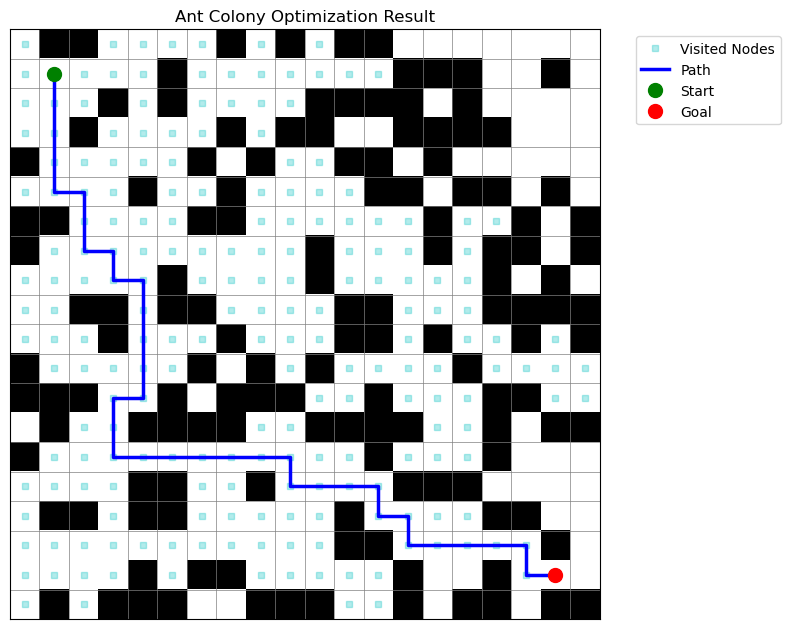

: 

In [ ]:
import random
import numpy as np

class ACOPathfinder:
    def __init__(self, env, num_ants=30, num_iterations=40, alpha=1.0, beta=2.0, evaporation_rate=0.1, Q=10.0):
        self.env = env
        self.num_ants = num_ants             # Number of ants per iteration
        self.num_iterations = num_iterations # Total number of iterations (generations)
        self.alpha = alpha                   # Importance of pheromone
        self.beta = beta                     # Importance of heuristic information
        self.evaporation_rate = evaporation_rate # Pheromone evaporation rate (rho)
        self.Q = Q                           # Pheromone deposit constant
        
        # Initialize pheromone matrix; all cells start with 1.0
        self.pheromones = np.ones((env.height, env.width))
        
        self.best_path = None
        self.best_path_length = float('inf')
        self.all_visited_nodes = set()       # Track all nodes visited by any ant for visualization

    def heuristic(self, node):
        """
        Heuristic function: Inverse of Manhattan Distance.
        The closer to the goal, the higher the value, encouraging ants to move forward.
        """
        dist = abs(node[0] - self.env.goal[0]) + abs(node[1] - self.env.goal[1])
        return 1.0 / (dist + 1.0) # Add 1 to avoid division by zero

    def search(self):
        print(f"ACO search started ({self.num_iterations} iterations)...")
        for iteration in range(self.num_iterations):
            all_paths = []
            
            # 1. Ant colony explores paths (simulated via loop)
            for ant in range(self.num_ants):
                path = self.construct_path()
                if path: # If the ant successfully reached the goal
                    all_paths.append(path)
                    # Update global best path
                    if len(path) < self.best_path_length:
                        self.best_path = path
                        self.best_path_length = len(path)

            # 2. Update pheromones across the map after the generation completes
            self.update_pheromones(all_paths)
            
            # Print progress every 10 iterations
            if (iteration + 1) % 10 == 0:
                best_len = self.best_path_length if self.best_path else 'None'
                print(f"Iteration {iteration + 1} complete. Current best path length: {best_len}")
                
        return self.best_path, list(self.all_visited_nodes)

    def construct_path(self):
        """Simulates a single ant finding a path from start to goal"""
        path = [self.env.start]
        visited = {self.env.start} # Tabu list for this specific ant to prevent loops
        self.all_visited_nodes.add(self.env.start)
        current = self.env.start

        while current != self.env.goal:
            neighbors = self.env.get_neighbors(current)
            # Filter out nodes already visited by this ant
            unvisited_neighbors = [n for n in neighbors if n not in visited]
            
            if not unvisited_neighbors:
                return None # Ant reached a dead end

            # Calculate transition probabilities for each neighbor
            probabilities = []
            for neighbor in unvisited_neighbors:
                tau = self.pheromones[neighbor] # Pheromone level at the neighbor
                eta = self.heuristic(neighbor)  # Heuristic value
                prob = (tau ** self.alpha) * (eta ** self.beta)
                probabilities.append(prob)

            # Roulette wheel selection for the next node
            total_prob = sum(probabilities)
            if total_prob == 0:
                next_node = random.choice(unvisited_neighbors)
            else:
                probabilities = [p / total_prob for p in probabilities]
                # Random choice based on calculated weights
                next_node = random.choices(unvisited_neighbors, weights=probabilities, k=1)[0]

            path.append(next_node)
            visited.add(next_node)
            self.all_visited_nodes.add(next_node)
            current = next_node

        return path

    def update_pheromones(self, all_paths):
        """Update pheromones: tau_ij = (1-rho) * tau_ij + Delta_tau_ij"""
        # 1. Global pheromone evaporation
        self.pheromones *= (1.0 - self.evaporation_rate)
        
        # 2. Reinforcement: Successful ants deposit new pheromones
        for path in all_paths:
            # Shorter paths result in higher pheromone density
            pheromone_to_add = self.Q / len(path)
            for node in path:
                self.pheromones[node] += pheromone_to_add

# --- Run ACO Algorithm and Visualize ---
# Using the 'env' object created in Block 1
aco_planner = ACOPathfinder(env, num_ants=40, num_iterations=50)

# Execute search
aco_path, aco_visited = aco_planner.search()

# Visualize results
if aco_path:
    print(f"\nACO found a path! Best path length: {len(aco_path) - 1} steps.")
    env.plot(path=aco_path, visited=aco_visited, title="Ant Colony Optimization Result")
else:
    print("\nACO failed to find a path (parameter tuning or more iterations may be needed).")
    env.plot(visited=aco_visited, title="ACO Failed")